
Things I want to do with this code
- create CA area of interest (CA + surrounding states)
- create CA power grid (hopefully doing some local validation tests on the HIFLD grid data) 
    - somehow widen that representation to include capacity of the elements (transmission lines and substations)
    - some way of revealing cascading dynamics (and identifying on the map of outages)
    - incorporate whatever data can be found on Public Safety Power Shutoffs (PSPS) and identify on the movie
- get the data that Yuliya (terrestrial wx) and Nick (wildfire) shared
    - using what we have learned to identify the critical variables/approaches to encoding each of these hazards from a power grid impact perspective
- build a chunked approach to data ingest: given a user-specified timespan, get the data from all hazards into a grid
- get the eagle-I data on outages and make a movie for all of 2024 with some indication of critical times of outages (time series + county-level indication)
- calculate power grid impacts/stresses based on hazards, interactions, preconditioning, topology, cascading conditions
- relating the information to important information for power grid reliability and resilience practitioners





In [ ]:
import pandas as pd
import geopandas as gpd
import os, re
from shapely.geometry import Point, Polygon, MultiPolygon
import numpy as np

import numpy as np
from typing import Literal

from datetime import datetime, time
import geopandas as gpd
import xarray as xr

import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

import rioxarray

import requests
import json
from shapely.geometry import shape


# Define Functions

# Get power grid as our background network

In [ ]:
file_path_powergrid = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/physical_grid_data/U.S._Electric_Power_Transmission_Lines.geojson"
gdf_powergrid = gpd.read_file(file_path_powergrid)



# Convert timeframes to folium-friendly types
gdf_powergrid['SOURCEDATE'] = pd.to_datetime(gdf_powergrid['SOURCEDATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')
gdf_powergrid['VAL_DATE'] = pd.to_datetime(gdf_powergrid['VAL_DATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')


# Drop columns with 'NOT AVAILABLE' as substation value
# gdf[ (gdf['SUB_1']=='NOT AVAILABLE') | (gdf['SUB_2']=='NOT AVAILABLE')]
condition = ( (gdf_powergrid['SUB_1']=='NOT AVAILABLE') | (gdf_powergrid['SUB_2']=='NOT AVAILABLE') )
gdf_powergrid = gdf_powergrid[~condition]
# gdf

# Drop columns with 'NONE' as substation value
condition = ( (gdf_powergrid['SUB_1']=='NONE') | (gdf_powergrid['SUB_2']=='NONE') )
gdf_powergrid = gdf_powergrid[~condition]
gdf_powergrid



# Define Area of Interest

In [ ]:
file_path_aoi = "/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/ca_and_bordering_states.geojson"
gdf_aoi = gpd.read_file(file_path_aoi)
gdf_aoi = gdf_aoi.to_crs(gdf_powergrid.crs)

In [ ]:
# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid, gdf_aoi, how="inner", predicate='within').drop(columns=['index_right'])

In [ ]:
# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid_aoi, gdf_aoi, how="inner", predicate='within').drop(columns=['index_right'])


## Create tiled grid

In [17]:
# Create tiles and map AOI to tiles

# =============================================================================
# Tile Generator: AOI → Tile Grid
# Supports square or hexagon grid generation over a GeoPandas AOI
# =============================================================================

def generate_tiles_over_aoi(
    aoi_gdf: gpd.GeoDataFrame,
    resolution_km: float = 50.0,
    shape: Literal["square", "hex"] = "square",
    crs: str = "EPSG:5070",
):
    """
    Generate a grid of square or hexagonal tiles fully covering an AOI.
    Only tiles that intersect the AOI are returned.

    Parameters
    ----------
    aoi_gdf : GeoDataFrame
        Input AOI polygons (any CRS). Can be multipolygon.
    resolution_km : float
        Target tile resolution in kilometers.
    shape : {"square", "hex"}
        Tile geometry type.
    crs : str
        Output / working CRS (must be projected). Default EPSG:5070.

    Returns
    -------
    tiles : GeoDataFrame
        Grid tiles intersecting the AOI.
    """
    import shapely.geometry as geom

    # --- Reproject AOI into equal‑area units
    aoi = aoi_gdf.to_crs(crs)
    minx, miny, maxx, maxy = aoi.total_bounds

    res_m = resolution_km * 1000.0

    # --- Buffer AOI extents so boundary tiles are not missed
    buffer = res_m * 2
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer

    tiles = []

    if shape == "square":
        x_coords = np.arange(minx, maxx, res_m)
        y_coords = np.arange(miny, maxy, res_m)

        for x in x_coords:
            for y in y_coords:
                poly = geom.Polygon(
                    [
                        (x, y),
                        (x + res_m, y),
                        (x + res_m, y + res_m),
                        (x, y + res_m),
                    ]
                )
                tiles.append(poly)

    elif shape == "hex":
        w = res_m
        h = np.sqrt(3) * w / 2

        x_coords = np.arange(minx, maxx + w, w * 3/4)
        y_coords = np.arange(miny, maxy + h, h)

        for i, x in enumerate(x_coords):
            for j, y in enumerate(y_coords):
                # offset every other row
                x_offset = x + (w * 0.5 if j % 2 else 0)
                hex_poly = geom.Polygon(_hexagon_vertices(x_offset, y, w/2))
                tiles.append(hex_poly)

    else:
        raise ValueError("Shape must be 'square' or 'hex'")

    # --- Build GeoDataFrame and intersect with AOI
    grid = gpd.GeoDataFrame({"geometry": tiles}, crs=crs)
    grid = gpd.overlay(grid, aoi, how="intersection")

    # Assign tile IDs
    grid["tile_id"] = [f"T{i:07d}" for i in range(len(grid))]

    return grid


def _hexagon_vertices(x_center: float, y_center: float, r: float):
    """Return coordinates for a hexagon centered at (x, y) with radius r."""
    angles = np.linspace(0, 2 * np.pi, num=7)[:-1]
    return [(x_center + r * np.cos(a), y_center + r * np.sin(a)) for a in angles]


In [18]:
# First, check the CRS and bounds of the power grid AOI
print("Power grid AOI info:")
print(f"  CRS: {gdf_powergrid_aoi.crs}")
print(f"  Bounds: {gdf_powergrid_aoi.total_bounds}")
print(f"  Number of features: {len(gdf_powergrid_aoi)}")

# Generate tiles over the power grid AOI
# Note: Using the dissolved union of the AOI for better tile coverage
tiles_gdf = generate_tiles_over_aoi(
    aoi_gdf=gdf_aoi,  # Use the original AOI polygon instead of the power grid lines
    resolution_km=50.0,  # 50 km tiles
    shape="square",      # or "hex" for hexagonal tiles
    crs="EPSG:5070"      # Equal-area projection for US
)

print(f"\nGenerated {len(tiles_gdf)} tiles covering the AOI")
if len(tiles_gdf) > 0:
    print(f"Tile CRS: {tiles_gdf.crs}")
    print(f"Tile bounds: {tiles_gdf.total_bounds}")
    tiles_gdf.head()
else:
    print("WARNING: No tiles generated!")

Power grid AOI info:
  CRS: EPSG:4326
  Bounds: [-124.61138331   31.36225233 -109.11295561   48.9927806 ]
  Number of features: 10128

Generated 733 tiles covering the AOI
Tile CRS: EPSG:5070
Tile bounds: [-2356114.04758029  1002286.89288089 -1146479.98261186  3172567.86552952]


/var/folders/s_/nsj8l6gd247cf7v6b5_pnsm00000gp/T/ipykernel_12142/3180944339.py:86: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  grid = gpd.overlay(grid, aoi, how="intersection")


In [19]:
target_crs = 'EPSG:4326'  # Keep in lat/lon for consistency with source data

print(f"\n{'='*60}")
print(f"Standardizing all geodataframes to {target_crs}")
print(f"{'='*60}")

# Reproject tiles_gdf to match
if tiles_gdf.crs != target_crs:
    print(f"Reprojecting tiles_gdf from {tiles_gdf.crs} to {target_crs}...")
    tiles_gdf = tiles_gdf.to_crs(target_crs)
    print("✓ tiles_gdf reprojected")

# Ensure gdf_aoi matches (should already be 4326)
if gdf_aoi.crs != target_crs:
    print(f"Reprojecting gdf_aoi from {gdf_aoi.crs} to {target_crs}...")
    gdf_aoi = gdf_aoi.to_crs(target_crs)
    print("✓ gdf_aoi reprojected")

print(f"\nFinal CRS verification:")
print(f"  gdf_aoi: {gdf_aoi.crs}")
print(f"  tiles_gdf: {tiles_gdf.crs}")
print(f"  gdf_powergrid_aoi: {gdf_powergrid_aoi.crs}")


Standardizing all geodataframes to EPSG:4326
Reprojecting tiles_gdf from EPSG:5070 to EPSG:4326...
✓ tiles_gdf reprojected

Final CRS verification:
  gdf_aoi: EPSG:4326
  tiles_gdf: EPSG:4326
  gdf_powergrid_aoi: EPSG:4326


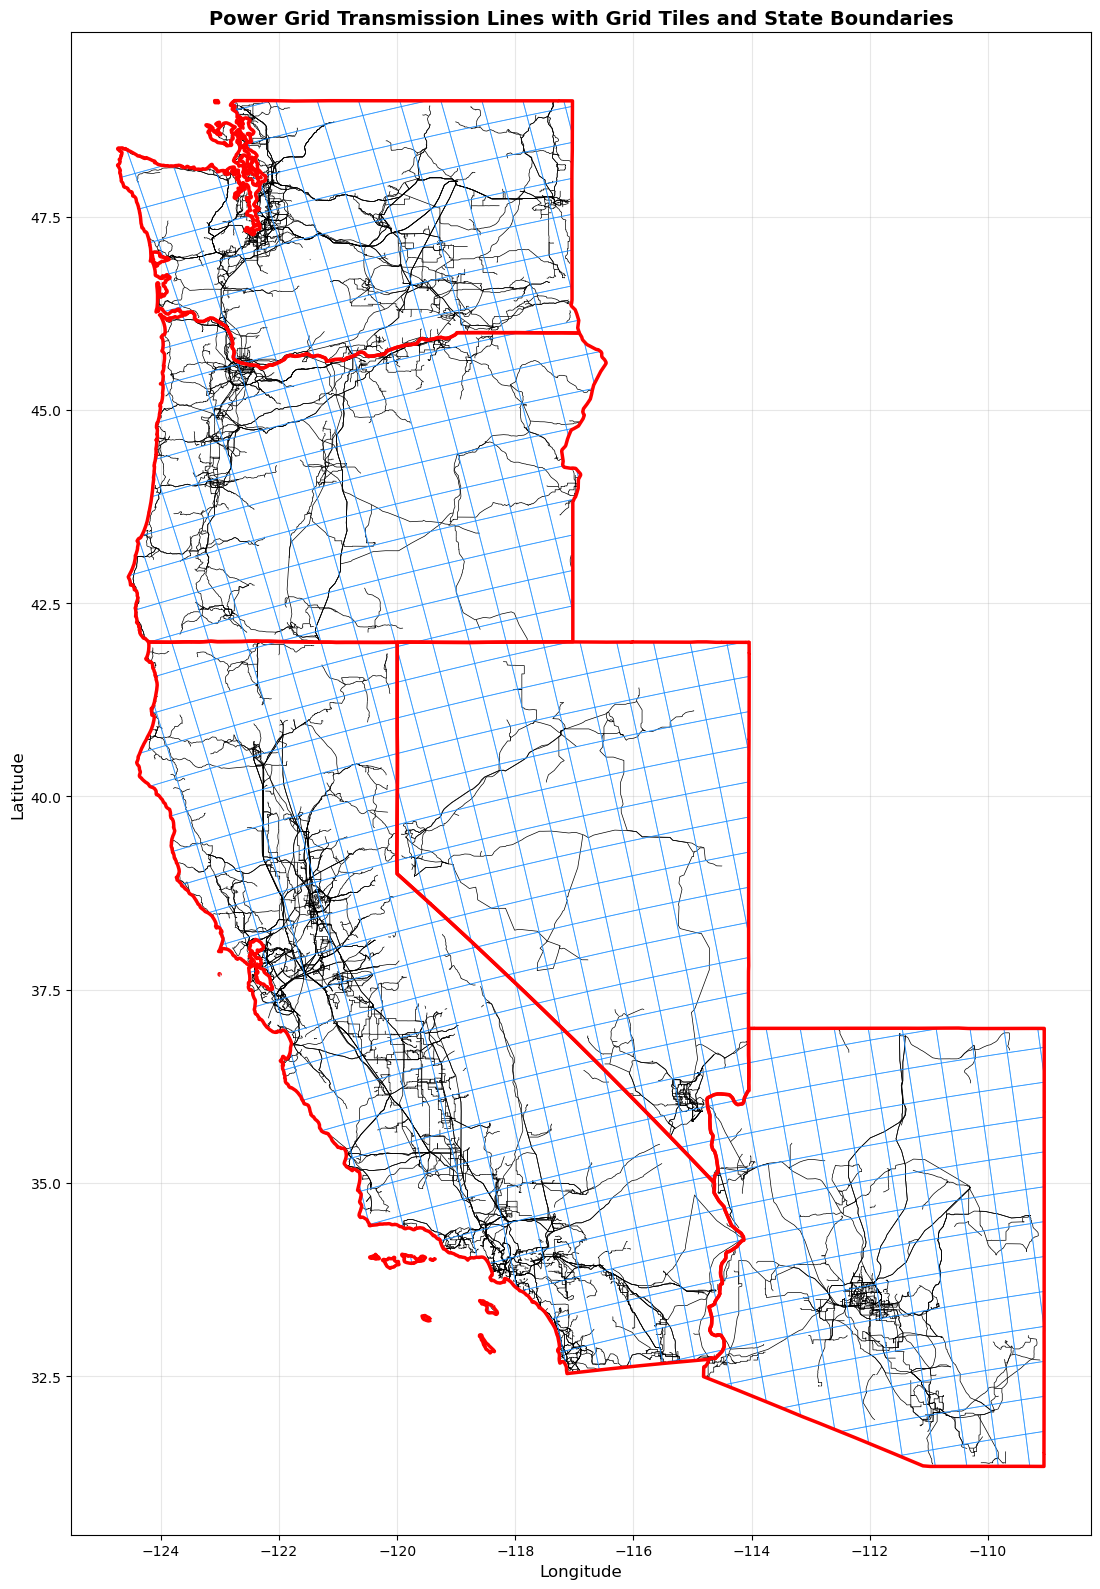

In [22]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(20, 16))

# Ensure layer CRS consistency for plotting
if tiles_gdf.crs != gdf_aoi.crs:
    tiles_plot = tiles_gdf.to_crs(gdf_aoi.crs)
else:
    tiles_plot = tiles_gdf

if gdf_powergrid_aoi.crs != gdf_aoi.crs:
    powergrid_plot = gdf_powergrid_aoi.to_crs(gdf_aoi.crs)
else:
    powergrid_plot = gdf_powergrid_aoi

# Plot power grid transmission lines
powergrid_plot.plot(ax=ax, color='black', linewidth=0.5, label='Transmission Lines', zorder=2)

# Overlay grid tiles
tiles_plot.boundary.plot(ax=ax, color='dodgerblue', linewidth=0.6, alpha=0.7, label='Grid Tiles', zorder=3)

# Overlay state boundaries on top with different styling
gdf_aoi.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2.5, label='State Boundaries', zorder=4)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Power Grid Transmission Lines with Grid Tiles and State Boundaries', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Below here will go the hazards data readers and mapping to the gdf_tiles

# Below is exploratory analysis

# get outage data for the AoI

In [ ]:
# Load EAGLE-I outage data for 2024
 
# Path to EAGLE-I data
eaglei_directory = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/'
eaglei_file = 'eaglei_outages_2024.csv'

print(f"Loading EAGLE-I data from {os.path.join(eaglei_directory, eaglei_file)}...")
outage_data = pd.read_csv(os.path.join(eaglei_directory, eaglei_file))

# Convert timestamp to datetime
outage_data['datetime'] = pd.to_datetime(outage_data['run_start_time'])

# Filter to study period (March 31 - April 4, 2023)
study_start = '2024-02-01'
study_end = '2024-03-01'
outage_filtered = outage_data[(outage_data['datetime'] >= study_start) & 
                               (outage_data['datetime'] <= study_end)].copy()

print(f"\nOriginal EAGLE-I data shape: {outage_data.shape}")
print(f"Filtered to study period: {outage_filtered.shape}")
print(f"\nColumns: {list(outage_filtered.columns)}")
print(f"\nDate range: {outage_filtered['datetime'].min()} to {outage_filtered['datetime'].max()}")
print(f"Temporal resolution: ~{(outage_filtered['datetime'].diff().max())}")
print(f"\nSample data:")
print(outage_filtered.head())

In [ ]:
# Resample to hourly resolution

print("\nResampling outage data to hourly resolution...")
# Group by county and hour, sum customers without power (include state and county for later use)
outage_filtered['datetime_hour'] = outage_filtered['datetime'].dt.floor('H')
outage_hourly = outage_filtered.groupby(['fips_code', 'state', 'county', 'datetime_hour'])['customers_out'].sum().reset_index()
outage_hourly.rename(columns={'datetime_hour': 'datetime'}, inplace=True)
print(f"outage_hourly shape: {outage_hourly.shape}")
print(f"\nSample hourly outage data:")
print(outage_hourly.head())

In [ ]:

# Load the US County GeoJSON file
counties_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
print(f"Downloading county geometries from {counties_url}...")
response = requests.get(counties_url)
counties_geojson = response.json()


# Convert to GeoDataFrame
counties_records = []
for feature in counties_geojson['features']:
    geom = shape(feature['geometry'])
    fips = feature['id']
    counties_records.append({
        'fips_code': fips,
        'geometry': geom
    })

counties_gdf = gpd.GeoDataFrame(counties_records, crs='EPSG:4326')
print(f"\nCounties GeoDataFrame shape: {counties_gdf.shape}")
print(f"CRS: {counties_gdf.crs}")
print(counties_gdf.head())

In [ ]:
# Ensure EAGLE-I hourly data has FIPS codes formatted correctly (5-digit string with leading zeros)
outage_hourly['fips_code'] = outage_hourly['fips_code'].astype(str).str.zfill(5)

# Merge hourly outage data with county geometries
outage_with_geom = counties_gdf.merge(outage_hourly, on='fips_code', how='inner')
outage_with_geom = gpd.GeoDataFrame(outage_with_geom, crs='EPSG:4326')

print(f"\nHourly outage data merged with county geometries: {outage_with_geom.shape}")
print(f"Records with geometry: {outage_with_geom['geometry'].notna().sum()}")
print(f"\nSample merged data:")
print(outage_with_geom[['fips_code', 'state', 'county', 'datetime', 'customers_out', 'geometry']].head())

# Create Animated Movie: Outages Over Time
Chloropleth map (bottom) with aggregated time series (top) showing customers out by county

In [ ]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# Get states in the AOI (normalize to uppercase)
states_in_aoi_raw = gdf_aoi['name'].unique() if 'name' in gdf_aoi.columns else gdf_aoi.index.unique()
states_in_aoi = sorted([s.upper() for s in states_in_aoi_raw])

# Filter outage data to only AOI (normalize state to uppercase for matching)
outage_in_aoi = outage_with_geom[outage_with_geom['state'].str.upper().isin(states_in_aoi)].copy()

# Prepare time series data for the top plot (filtered to AOI states)
# Aggregate by state and datetime (normalize state to uppercase)
outage_in_aoi['state_normalized'] = outage_in_aoi['state'].str.upper()
ts_by_state = outage_in_aoi.groupby(['state_normalized', 'datetime'])['customers_out'].sum().reset_index()
ts_by_state.rename(columns={'state_normalized': 'state'}, inplace=True)
ts_total = outage_in_aoi.groupby('datetime')['customers_out'].sum().reset_index()

# Sort by datetime
ts_by_state = ts_by_state.sort_values('datetime')
ts_total = ts_total.sort_values('datetime')

# Get unique times and states (only those in AOI)
unique_times = sorted(outage_in_aoi['datetime'].unique())
unique_states = sorted(ts_by_state['state'].unique())

# Get AOI bounds for zooming
aoi_bounds = gdf_aoi.total_bounds  # [minx, miny, maxx, maxy]

print(f"Total number of timesteps: {len(unique_times)}")
print(f"Date range: {unique_times[0]} to {unique_times[-1]}")
print(f"States in AOI: {unique_states}")
print(f"AOI bounds: {aoi_bounds}")


In [ ]:
# Test first frame before creating full animation
# Set up color mapping for states
state_colors = {state: cm.get_cmap('tab10')(i) for i, state in enumerate(unique_states)}

# Prepare data for chloropleth (only AOI counties)
outage_anim_data = outage_in_aoi.copy()

# Create normalization for the chloropleth
vmin = outage_anim_data['customers_out'].min()
vmax = outage_anim_data['customers_out'].max()
norm = Normalize(vmin=vmin, vmax=vmax)

def animate(frame_idx, save_frame=False, frame_path=None):
    """Update function for animation"""
    # Get current time
    current_time = unique_times[frame_idx]
    
    # Create figure with 2 subplots for each frame
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.3)
    ax_ts = fig.add_subplot(gs[0])
    ax_map = fig.add_subplot(gs[1])
    
    # === TOP PLOT: Time Series (only AOI states) ===
    # Plot total customers out (black line)
    ax_ts.plot(ts_total['datetime'], ts_total['customers_out'], 
              color='black', linewidth=2.5, label='Total (AOI)', zorder=2)
    
    # Plot each state's time series
    for state in unique_states:
        state_data = ts_by_state[ts_by_state['state'] == state]
        ax_ts.plot(state_data['datetime'], state_data['customers_out'], 
                  color=state_colors[state], linewidth=1.5, label=state, alpha=0.7)
    
    # Add vertical line at current time
    ax_ts.axvline(current_time, color='red', linewidth=2.5, linestyle='--', 
                 label=f'Current: {current_time.strftime("%Y-%m-%d %H:%M")}', zorder=3)
    
    ax_ts.set_xlabel('Date/Time', fontsize=11)
    ax_ts.set_ylabel('Customers Out', fontsize=11)
    ax_ts.set_title('Aggregated Outages Over Time (AOI States)', fontsize=12, fontweight='bold')
    ax_ts.legend(loc='upper left', fontsize=9, ncol=2)
    ax_ts.grid(True, alpha=0.3)
    ax_ts.set_xlim(ts_total['datetime'].min(), ts_total['datetime'].max())
    
    # === BOTTOM PLOT: Chloropleth Map (zoomed to AOI) ===
    # Get data for current timestep
    current_data = outage_anim_data[outage_anim_data['datetime'] == current_time].copy()
    
    # Plot base counties (only those in AOI)
    counties_in_aoi = counties_gdf[counties_gdf.geometry.bounds.apply(
        lambda row: (row.minx >= aoi_bounds[0] and row.miny >= aoi_bounds[1] and 
                     row.maxx <= aoi_bounds[2] and row.maxy <= aoi_bounds[3]), axis=1)]
    counties_in_aoi.plot(ax=ax_map, color='lightgray', edgecolor='white', linewidth=0.5)
    
    # Plot counties with outage data
    if len(current_data) > 0:
        current_data.plot(ax=ax_map, column='customers_out', cmap='YlOrRd', 
                         edgecolor='black', linewidth=0.3, norm=norm, 
                         legend=False, alpha=0.8)
    
    # Overlay state boundaries
    gdf_aoi.plot(ax=ax_map, edgecolor='darkblue', facecolor='none', linewidth=2, alpha=0.7)
    
    # Add colorbar
    sm = ScalarMappable(cmap='YlOrRd', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_map, orientation='vertical', pad=0.02)
    cbar.set_label('Customers Out', fontsize=11)
    
    ax_map.set_xlabel('Longitude', fontsize=11)
    ax_map.set_ylabel('Latitude', fontsize=11)
    ax_map.set_title(f'Outages by County: {current_time.strftime("%Y-%m-%d %H:%M UTC")}', 
                    fontsize=12, fontweight='bold')
    ax_map.grid(True, alpha=0.2)
    
    # Zoom to AOI
    ax_map.set_xlim(aoi_bounds[0], aoi_bounds[2])
    ax_map.set_ylim(aoi_bounds[1], aoi_bounds[3])
    
    # Save frame if requested
    if save_frame and frame_path:
        plt.tight_layout()
        fig.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
    
    return fig

# Test the first frame
print("Testing first frame...")
test_fig = animate(100)
plt.tight_layout()
plt.show()

In [ ]:
# Create full animation (run after confirming first frame looks good)
print("Creating full animation...")
frame_indices = list(range(0, len(unique_times), 1))  # Change step to reduce frames if needed

dir_frames = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_frames/CA_aoi_2024/"
if not os.path.exists(dir_frames):
    os.makedirs(dir_frames)
    print('making directory {}'.format(dir_frames))
    
dir_movie = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_movies/"

# Create output directory if it doesn't exist
os.makedirs(dir_frames, exist_ok=True)

# Save individual frames for later exploration
print(f"Saving {len(frame_indices)} individual frames...")
for idx in frame_indices:
    frame_filename = os.path.join(dir_frames, f"frame_{idx:05d}.png")
    animate(idx, save_frame=True, frame_path=frame_filename)
    if (idx + 1) % 50 == 0:
        print(f"  Saved {idx + 1}/{len(frame_indices)} frames")
print("Individual frames saved!")

print("\nTo create MP4 from frames, run:")
print(f"ffmpeg -framerate 4 -i {dir_frames}frame_%05d.png -c:v libx264 -pix_fmt yuv420p -b:v 1800k {dir_movie}outages_animation.mp4")